<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

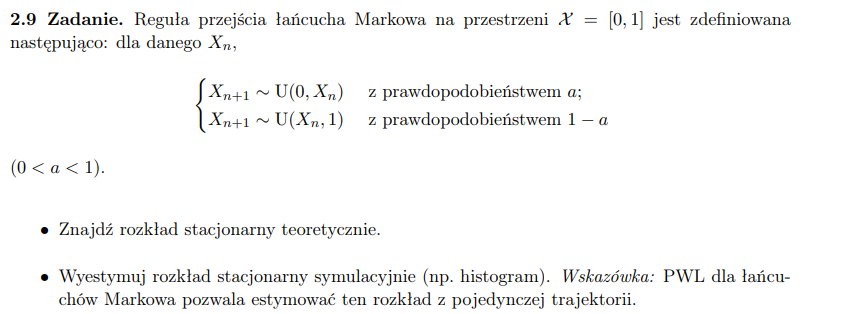

### Stationary distribution
---
Let $\pi(x)$ be desired stationary distribution. We can easily observe that density of stationary distribution must satisfy:

$$\pi(y) = \int_0^1 \pi(x) p(y|x) dx,$$

where $p(y|x)$ is density of transition from state $x$ to state $y$.

Now, we must find the formula for $p(y|x)$ to calculate $\pi$.



*   if $y<x$, this mean that we drew transition from $U(0,x)$. The probability od this event is $a$. Density of $U(0,x)$ is $1/x$. Therefore, for $y<x$, we have $p(y|x)=\frac{a}{x}$
*   if $x<y$, this mean that we drew transition from $U(x,1)$. The probability od this event is $1-a$. Density of $U(x,1)$ is $\frac{1}{1-x}$. Therefore, for $x<y$, we have $p(y|x)=\frac{1-a}{1-x}$

We may proceed with computation of $\pi$:

$$\pi(y) = \int_0^y \pi(x) \frac{1-a}{1-x} dx + \int_y^1 \pi(x) \frac{a}{x} dx$$

Then, we apply differentiation to both sides of equation:

$$\pi'(y) = \frac{d}{dy} \left( \int_0^y \pi(x) \frac{1-a}{1-x} dx \right) + \frac{d}{dy} \left( \int_y^1 \pi(x) \frac{a}{x} dx \right)$$
$$\pi'(y) = \pi(y) \frac{1-a}{1-y} - \pi(y) \frac{a}{y}$$
$$\frac{\pi'(y)}{\pi(y)} = \frac{1-a}{1-y} - \frac{a}{y}$$
$$\pi(y) = K \cdot y^{(1-a)-1} (1-y)^{a-1}$$

Observe that this stationary distribution corresponds to $Beta(1-a, a)$ distribution. As a result: $\pi \sim Beta(1-a, a)$



### Simulations
---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

In [4]:
def sampler(a=0.5, x0=0.5, n=100):
  trajectory = [x0]
  u_vector = np.random.rand(n)
  for i in range(n):
    if u_vector[i] < a:
      trajectory.append(np.random.uniform(0, trajectory[-1]))
    else:
      trajectory.append(np.random.uniform(trajectory[-1], 1))
  return trajectory

In [10]:
a = 0.5
trajectory = sampler(a=a, n=1000000)
trajectory_burnout = trajectory[1000:]

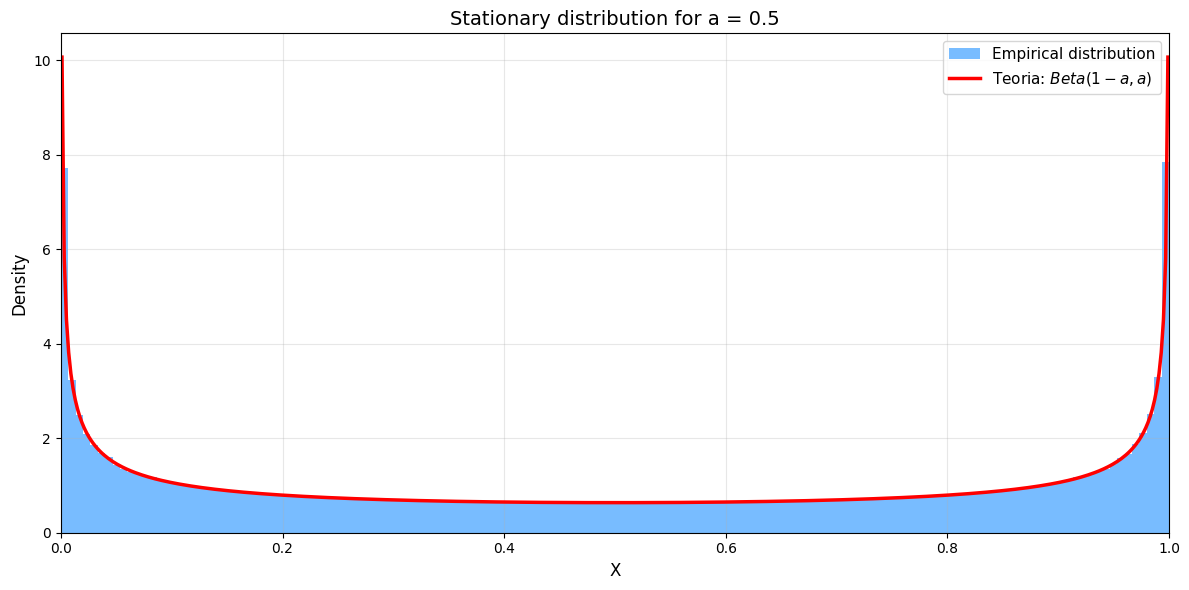

In [11]:
plt.figure(figsize=(12, 6))
plt.hist(trajectory_burnout, bins=150, density=True, alpha=0.6, color='dodgerblue',
         label='Empirical distribution')

x_vals = np.linspace(0.001, 0.999, 500)
pdf_teoret = beta.pdf(x_vals, 1 - a, a)

plt.plot(x_vals, pdf_teoret, 'r-', lw=2.5,
         label=r'Teoria: $Beta(1-a, a)$')

plt.title(f'Stationary distribution for a = {a}', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
a = 0.4
trajectory = sampler(a=a, n=1000000)
trajectory_burnout = trajectory[1000:]

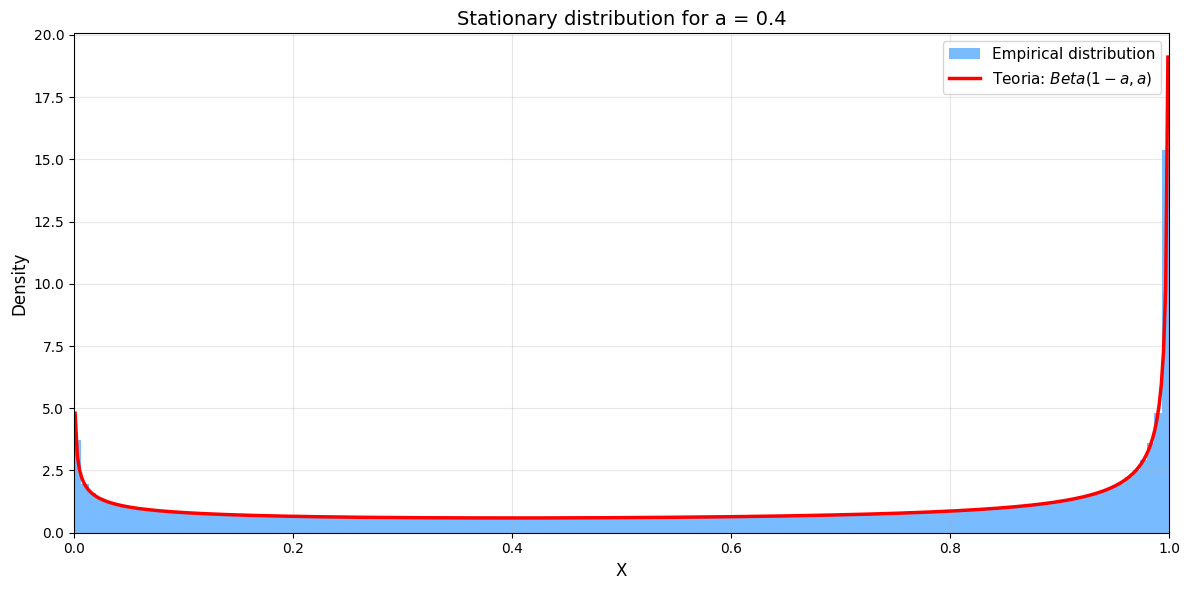

In [16]:
plt.figure(figsize=(12, 6))
plt.hist(trajectory_burnout, bins=150, density=True, alpha=0.6, color='dodgerblue',
         label='Empirical distribution')

x_vals = np.linspace(0.001, 0.999, 500)
pdf_teoret = beta.pdf(x_vals, 1 - a, a)

plt.plot(x_vals, pdf_teoret, 'r-', lw=2.5,
         label=r'Teoria: $Beta(1-a, a)$')

plt.title(f'Stationary distribution for a = {a}', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
a = 0.9
trajectory = sampler(a=a, n=1000000)
trajectory_burnout = trajectory[1000:]

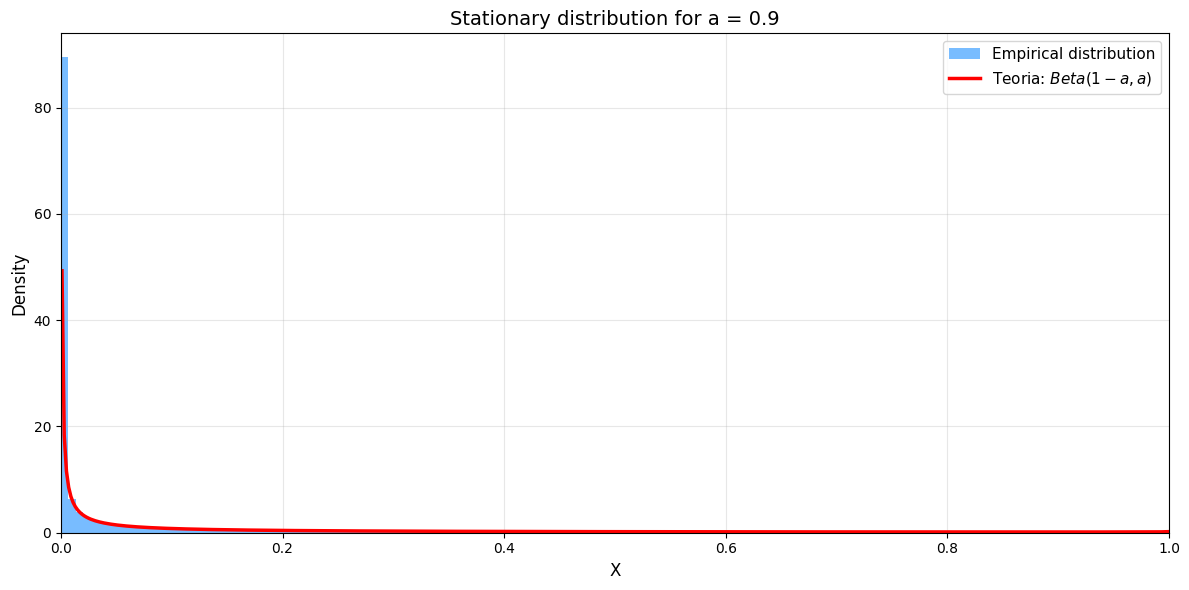

In [18]:
plt.figure(figsize=(12, 6))
plt.hist(trajectory_burnout, bins=150, density=True, alpha=0.6, color='dodgerblue',
         label='Empirical distribution')

x_vals = np.linspace(0.001, 0.999, 500)
pdf_teoret = beta.pdf(x_vals, 1 - a, a)

plt.plot(x_vals, pdf_teoret, 'r-', lw=2.5,
         label=r'Teoria: $Beta(1-a, a)$')

plt.title(f'Stationary distribution for a = {a}', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()